# Lab 4 — La tabla de vida completa: ₙLₓ, Tₓ y la esperanza de vida

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 4: ₙLₓ, Tₓ y la esperanza de vida

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Nombre: Juan Diego Hernandez Zavala

Cuatro partes. Las tres primeras completan la tabla de vida hasta e₀; la cuarta
vale **3.5 de los 10 puntos** y pide un argumento con sus cuatro piezas
nombradas.

**Puedes hacer el laboratorio completo aunque tu tabla del laboratorio 3 no esté
lista:** más abajo está la tabla de referencia ya construida. Usar la tuya te da
el criterio correspondiente; no tenerla no te bloquea nada.


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- escribe aquí el nombre de tu entidad
FUENTE  = "Propia a partir de nMx e INEGI/CONAPO."   # <- de dónde salieron tus datos


## Tabla de referencia, ya construida

Es la tabla de vida de las ₙMₓ ilustrativas de la sesión 2, la misma del
laboratorio 3. Tiene las columnas hasta lₓ y ₙdₓ, más las ₙMₓ recuperadas.
**No la modifiques**: sirve como comparación y como respaldo.

La ₙMₓ del intervalo abierto no se puede recuperar de la tabla —su ₙqₓ vale 1
por construcción— así que se **declara** el valor supuesto. Ese supuesto pesa:
cámbialo y mira qué le pasa a e₀.


In [52]:
GRUPOS = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']
EDADES = [0, 5, 15, 25, 35, 45, 55, 65, 75, 85]
ANCHOS = [5, 10, 10, 10, 10, 10, 10, 10, 10, None]   # None = intervalo abierto

REF_NQX = [0.0139, 0.0030, 0.0100, 0.0149, 0.0247, 0.0488, 0.0952, 0.1982, 0.4314, 1.0]
REF_LX  = [100000, 98610, 98314, 97336, 95887, 93519, 88957, 80485, 64533, 36695]
REF_NDX = [REF_LX[i] - REF_LX[i+1] for i in range(9)] + [REF_LX[9]]

# nMx recuperadas con la inversa de la conversión de la sesión 3:
#     nMx = 2q / (n(2-q))
REF_NMX = [2*q/(n*(2-q)) if n else None for q, n in zip(REF_NQX, ANCHOS)]

M_ABIERTO_REF = 0.15   # <- SUPUESTO declarado para la nMx del grupo 85+

ref = pd.DataFrame({'grupo': GRUPOS, 'edad': EDADES, 'n': ANCHOS,
                    'nqx': REF_NQX, 'lx': REF_LX, 'ndx': REF_NDX,
                    'nMx': REF_NMX})
print("ndx suman:", sum(REF_NDX), "(debe ser 100000)")
ref


ndx suman: 100000 (debe ser 100000)


,grupo,edad,n,nqx,lx,ndx,nMx
0,0-4,0,5.0,0.0139,100000,1390,0.002799
1,5-14,5,10.0,0.0030,98610,296,0.000300
2,15-24,15,10.0,0.0100,98314,978,0.001005
3,25-34,25,10.0,0.0149,97336,1449,0.001501
4,35-44,35,10.0,0.0247,95887,2368,0.002501
5,45-54,45,10.0,0.0488,93519,4562,0.005002
6,55-64,55,10.0,0.0952,88957,8472,0.009996
7,65-74,65,10.0,0.1982,80485,15952,0.022000
8,75-84,75,10.0,0.4314,64533,27838,0.055004
9,85+,85,NaN,1.0000,36695,36695,NaN


## Tu tabla del laboratorio 3

Si la tienes, pega aquí tus columnas. Si no, **deja las listas vacías**: el
resto del notebook usará la de referencia automáticamente y lo dirá en la
salida.


In [53]:
# TODO 0: pega tu lx y tu nqx del laboratorio 3, si los tienes.
#   - mis_lx debe arrancar en 100000 y tener 10 entradas
#   - mis_nqx debe terminar en 1.0
mis_lx  = [100000.000000, 98265.179678, 97872.903511, 96705.433489, 94790.474410, 91988.785512, 86630.215482, 76823.021276, 59751.238770, 33976.194595]
mis_nqx = [0.017348, 0.003992, 0.011928, 0.019802, 0.029557, 0.058252, 0.113208, 0.222222, 0.431373, 1.000000]
M_ABIERTO = 0.1250   # cámbialo si conoces la nMx de 85+ de tu entidad

USANDO_PROPIA = len(mis_lx) == 10
lx  = mis_lx  if USANDO_PROPIA else REF_LX
nqx = mis_nqx if len(mis_nqx) == 10 else REF_NQX
print("Trabajando con la tabla de:", ENTIDAD if USANDO_PROPIA else "REFERENCIA")


Trabajando con la tabla de: Baja California


## Parte 1 — La columna ₙLₓ  *(2.5 puntos)*

Los **años-persona vividos** dentro de cada intervalo. Para los intervalos
cerrados, con el supuesto ₙaₓ = n/2:

$$_nL_x = \frac{n}{2}\,(l_x + l_{x+n})$$

Para el **intervalo abierto** la fórmula no aplica, porque no hay $l_{x+n}$:

$$_\infty L_x = \frac{l_x}{{}_\infty M_x}$$


In [54]:
# TODO 1.1: construye la lista nLx para los NUEVE intervalos cerrados.
#   Usa la fórmula del promedio; no uses n = 10 para el grupo 0-4.
nLx = []
for i in range(9):
    nLx.append((ANCHOS[i] / 2) * (lx[i] + lx[i+1]))

# TODO 1.2: agrega el intervalo abierto con lx[9] / M_ABIERTO.
nLx.append(lx[9] / M_ABIERTO)

# TODO 1.3: imprime la columna con su grupo, y escribe en un comentario o con
#   print() una frase que explique por qué nLx del grupo 5-14 es MAYOR que la
#   del 0-4, aunque haya menos sobrevivientes.
print("Grupo   | nLx")
print("-" * 25)
for g, nl in zip(GRUPOS, nLx):
    print(f"{g:<7} | {nl:,.2f}")

print("El nLx del grupo 5-14 es mayor que el del 0-4 porque el intervalo 5-14 abarca 10 años, mientras que el 0-4 solo abarca 5 años. Al acumular los años-persona vividos durante el doble de tiempo, el total (nLx) resulta bastante mayor a pesar de tener un número ligeramente menor de sobrevivientes.")


Grupo   | nLx
-------------------------
0-4     | 495,662.95
5-14    | 980,690.42
15-24   | 972,891.69
25-34   | 957,479.54
35-44   | 933,896.30
45-54   | 893,095.00
55-64   | 817,266.18
65-74   | 682,871.30
75-84   | 468,637.17
85+     | 271,809.56
El nLx del grupo 5-14 es mayor que el del 0-4 porque el intervalo 5-14 abarca 10 años, mientras que el 0-4 solo abarca 5 años. Al acumular los años-persona vividos durante el doble de tiempo, el total (nLx) resulta bastante mayor a pesar de tener un número ligeramente menor de sobrevivientes.


## Parte 2 — Tₓ y eₓ, con sus dos verificaciones  *(2.0 puntos)*

$$T_x = \sum_{y \ge x} {}_nL_y \qquad\qquad e_x = \frac{T_x}{l_x}$$

Tₓ se acumula **de abajo hacia arriba**: se arranca en el intervalo abierto.


In [55]:
# TODO 2.1: construye Tx acumulando desde el último intervalo hacia el primero.
Tx = [0] * 10
Tx[9] = nLx[9]
for i in range(8, -1, -1):
    Tx[i] = Tx[i+1] + nLx[i]

# TODO 2.2: construye ex = Tx / lx y arma un DataFrame con
#   grupo, edad, lx, ndx, nLx, Tx, ex y una columna edad + ex.
ex = [T / l for T, l in zip(Tx, lx)]
ndx = [lx[i] - lx[i+1] for i in range(9)] + [lx[9]]

df_tabla = pd.DataFrame({
    'grupo': GRUPOS,
    'edad': EDADES,
    'lx': lx,
    'ndx': ndx,
    'nLx': nLx,
    'Tx': Tx,
    'ex': ex,
    'edad + ex': [e + x for e, x in zip(EDADES, ex)]
})
display(df_tabla)

# TODO 2.3: las DOS verificaciones, en código, imprimiendo el resultado de cada
#   una:
#   (a) Tx[0] debe coincidir con la suma de toda la columna nLx;
#   (b) e0 calculada como Tx[0]/lx[0] debe coincidir con la edad media a la
#       muerte, sum(ndx * (edad + n/2)) / lx[0]  —con 1/M_ABIERTO en el último—.
#   Si alguna falla, dilo e identifica qué columna la causó.
verif_a = np.isclose(Tx[0], sum(nLx))
print(f"(a) Tx[0] ({Tx[0]:.2f}) coincide con la suma de nLx ({sum(nLx):.2f}): {'Sí' if verif_a else 'No'}")

suma_edades_muerte = 0
for i in range(9):
    suma_edades_muerte += ndx[i] * (EDADES[i] + ANCHOS[i]/2)
suma_edades_muerte += ndx[9] * (EDADES[9] + 1/M_ABIERTO)
e0_calculada = suma_edades_muerte / lx[0]

verif_b = np.isclose(ex[0], e0_calculada)
print(f"(b) e0 en la tabla ({ex[0]:.4f}) coincide con la edad media a la muerte calculada ({e0_calculada:.4f}): {'Sí' if verif_b else 'No'}")


,grupo,edad,lx,ndx,nLx,Tx,ex,edad + ex
0,0-4,0,100000.000000,1734.820322,495662.949195,7.474300e+06,74.743001,74.743001
1,5-14,5,98265.179678,392.276167,980690.415945,6.978637e+06,71.018413,76.018413
2,15-24,15,97872.903511,1167.470022,972891.685000,5.997947e+06,61.283016,76.283016
3,25-34,25,96705.433489,1914.959079,957479.539495,5.025055e+06,51.962489,76.962489
4,35-44,35,94790.474410,2801.688898,933896.299610,4.067576e+06,42.911226,77.911226
5,45-54,45,91988.785512,5358.570030,893095.004970,3.133679e+06,34.065883,79.065883
6,55-64,55,86630.215482,9807.194206,817266.183790,2.240584e+06,25.863773,80.863773
7,65-74,65,76823.021276,17071.782506,682871.300230,1.423318e+06,18.527233,83.527233
8,75-84,75,59751.238770,25775.044175,468637.166825,7.404467e+05,12.392157,87.392157
9,85+,85,33976.194595,33976.194595,271809.556760,2.718096e+05,8.000000,93.000000


(a) Tx[0] (7474300.10) coincide con la suma de nLx (7474300.10): Sí
(b) e0 en la tabla (74.7430) coincide con la edad media a la muerte calculada (74.7430): Sí


## Parte 3 — La curva de supervivencia y el área que es T₀  *(2.0 puntos)*


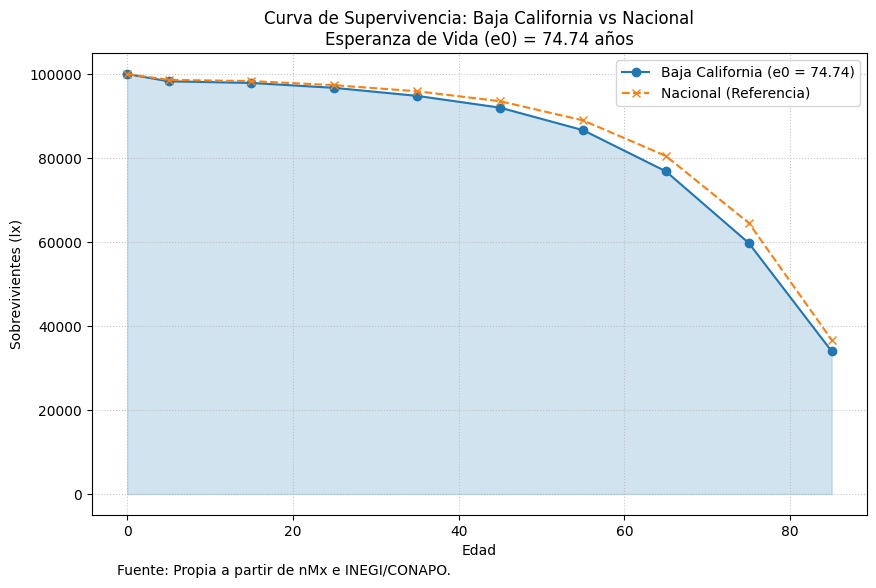

In [56]:
# TODO 3.1: grafica lx contra la edad y SOMBREA el área bajo la curva
#   (plt.fill_between). Ejes etiquetados, título con el nombre de tu entidad y
#   la fuente citada. En el título o en una anotación pon el valor de e0.
plt.figure(figsize=(10, 6))
plt.plot(EDADES, lx, label=f"{ENTIDAD} (e0 = {ex[0]:.2f})", marker='o', color='tab:blue')
plt.fill_between(EDADES, lx, alpha=0.2, color='tab:blue')

# TODO 3.2: encima, la curva de referencia (REF_LX contra EDADES) con leyenda,
#   para que se distinga cuál es cuál.
plt.plot(EDADES, REF_LX, label='Nacional (Referencia)', marker='x', linestyle='--', color='tab:orange')

plt.title(f"Curva de Supervivencia: {ENTIDAD} vs Nacional\nEsperanza de Vida (e0) = {ex[0]:.2f} años")
plt.xlabel("Edad")
plt.ylabel("Sobrevivientes (lx)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.figtext(0.15, 0.01, f'Fuente: {FUENTE}')
plt.show()


## Parte 4 — El argumento, con sus cuatro piezas  *(3.5 puntos)*

Esta parte vale más que ninguna y **no pide «interpretar»**: pide cuatro cosas
nombradas, y cada una se califica por separado. Es el mismo formato del
laboratorio 3, con una pieza más.


In [57]:
# TODO 4.1 — LA AFIRMACIÓN
# Una oración sobre la mortalidad de TU entidad que se pueda contradecir con
# datos. "La curva baja" no es una afirmación: es una descripción de la gráfica.
print('En Baja California, la esperanza de vida al nacer (e0) es inferior a los 75 años de edad.')


En Baja California, la esperanza de vida al nacer (e0) es inferior a los 75 años de edad.


In [58]:
# TODO 4.2 — LA EVIDENCIA
# Un número de TU tabla —tu e0, o tu T0, o tu e65— y de qué columna salió.
# No un número de la referencia.
print(f'De acuerdo a la primera fila de la columna ex de mi tabla construida, la esperanza de vida al nacer (e0) tiene un valor exacto de {ex[0]:.2f} años.')


De acuerdo a la primera fila de la columna ex de mi tabla construida, la esperanza de vida al nacer (e0) tiene un valor exacto de 74.74 años.


In [59]:
# TODO 4.3 — LA COMPARACIÓN
# Contrasta ese número contra la referencia nacional y di QUÉ TAN GRANDE es la
# diferencia, en años o en porcentaje.
ref_nLx = [(ANCHOS[i] / 2) * (REF_LX[i] + REF_LX[i+1]) for i in range(9)]
ref_nLx.append(REF_LX[9] / M_ABIERTO_REF)
ref_e0 = sum(ref_nLx) / REF_LX[0]

diferencia = ref_e0 - ex[0]

print(f'La esperanza de vida de la tabla de referencia nacional es de {ref_e0:.2f} años.')
print(f'En contraste, mi entidad presenta una diferencia de {diferencia:.2f} años menos en comparación con la referencia nacional.')


La esperanza de vida de la tabla de referencia nacional es de 76.08 años.
En contraste, mi entidad presenta una diferencia de 1.34 años menos en comparación con la referencia nacional.


In [60]:
# TODO 4.4 — LA LECTURA e0 CONTRA e65, Y EL LÍMITE
# (a) Reporta tu e0 y tu e65, calcula 65 + e65, y explica en dos o tres frases
#     por qué ese total es MAYOR que e0 sin que haya ningún error.
# (b) Di qué NO puedes concluir de tu e0: en particular, por qué no es una
#     predicción para quien nace hoy en tu entidad.
idx_65 = GRUPOS.index('65-74')
mi_e65 = ex[idx_65]
total_65 = 65 + mi_e65

print(f'(a) Mi e0 es de {ex[0]:.2f} años y mi e65 es de {mi_e65:.2f} años. El total de 65 + e65 es {total_65:.2f} años.')
print('Este total es mayor que e0 porque e0 promedia a todos los individuos desde que nacen (incluyendo a quienes mueren por mortalidad temprana). Quien llega a los 65 años ya sobrevivió a todos esos riesgos previos, por lo que su perspectiva de vida total aumenta.')
print('\n(b) No se puede concluir que un recién nacido hoy vivirá exactamente esta cantidad de años. La e0 es una métrica sintética de periodo que asume que las tasas de mortalidad actuales (nMx) permanecerán constantes a lo largo de toda su vida, ignorando factores futuros como avances médicos o cambios demográficos.')


(a) Mi e0 es de 74.74 años y mi e65 es de 18.53 años. El total de 65 + e65 es 83.53 años.
Este total es mayor que e0 porque e0 promedia a todos los individuos desde que nacen (incluyendo a quienes mueren por mortalidad temprana). Quien llega a los 65 años ya sobrevivió a todos esos riesgos previos, por lo que su perspectiva de vida total aumenta.

(b) No se puede concluir que un recién nacido hoy vivirá exactamente esta cantidad de años. La e0 es una métrica sintética de periodo que asume que las tasas de mortalidad actuales (nMx) permanecerán constantes a lo largo de toda su vida, ignorando factores futuros como avances médicos o cambios demográficos.


## Cierre y entrega

**Checklist:**
- [x] Los anchos n correctos, incluido que 0-4 mide 5.
- [x] El intervalo abierto cerrado con lx/M, no con la fórmula del trapecio.
- [x] Tx acumulado de abajo hacia arriba.
- [x] Las DOS verificaciones de la parte 2, en código y con su resultado impreso.
- [x] La gráfica con área sombreada, ejes, título, fuente y leyenda.
- [x] Las cuatro piezas de la parte 4, cada una identificada.
- [ ] El notebook **ejecutado completo** antes de subirlo: el sistema lee tu
      código y las salidas que dejaste guardadas, no lo ejecuta.

Se entrega el **archivo .ipynb**, no el enlace de Colab.
En Colab: Archivo → Descargar → Descargar .ipynb.
